# 02 Redline Color + Contour Probe v1

이 노트북은 final red line detector를 바로 확정하지 않는다.

Traffic light에서는 작은 lamp blob을 찾았다면, redline에서는 문제의 성격이 다르다.

```text
목표:
  바닥에 놓인 빨간 final line이 OpenCV 색 + contour로 분리되는지 확인한다.

핵심 질문:
  1. final redline의 빨간색은 HSV로 안정적으로 분리되는가?
  2. stop sign 같은 빨간 물체와 contour 형태가 충분히 다른가?
  3. redline은 horizontal / floor-like contour로 볼 수 있는가?
  4. 나중에 ROI를 넣기 전에, 색과 형태만으로 어느 정도 후보를 좁힐 수 있는가?
```

따라서 02의 산출물은 contract가 아니라 탐색 결과다. 다음 단계에서 필요하면 ROI, temporal voting, event trigger 조건을 별도로 좁힌다.


## 이번 노트북에서 보는 대상

`redline/raw` 폴더에는 실제 final redline 이미지와 stop sign negative 이미지가 같이 들어 있다.

```text
positive:
  final_redline       파일명에 redline 또는 finish가 들어간 이미지

negative:
  stop_sign_negative  파일명에 stop 또는 sign이 들어간 이미지

cross-check:
  traffic_red         빨간 신호등 이미지
  traffic_green       초록 신호등 이미지
```

특히 stop sign은 색만 보면 redline과 같은 빨간 계열이므로 반드시 negative로 따로 본다.


In [1]:
from pathlib import Path
from IPython.display import display, Image
import json
import math
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '18_opencv_color_event_detector'
DATA_ROOT = PROJECT_ROOT / '20_shared_assets' / 'dataset'
TRAFFIC_ROOT = DATA_ROOT / 'traffic' / 'raw'
REDLINE_ROOT = DATA_ROOT / 'redline' / 'raw'

OUT_ROOT = EXP_ROOT / 'review_outputs' / '02_redline_color_contour_probe_v1'
TABLE_DIR = OUT_ROOT / 'tables'
OVERLAY_DIR = OUT_ROOT / 'overlays'
PLOT_DIR = OUT_ROOT / 'plots'
for p in [TABLE_DIR, OVERLAY_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('EXP_ROOT:', EXP_ROOT)
print('REDLINE_ROOT:', REDLINE_ROOT)
print('OUT_ROOT:', OUT_ROOT)


EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector
REDLINE_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\redline\raw
OUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1


## Windows long-path helper

프로젝트 경로가 길어서 OpenCV I/O는 항상 long-path helper를 거친다. 18번 폴더의 앞 노트북들과 같은 방식이다.


In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    if os.name == 'nt' and len(s) >= 240 and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s

def exists_fs(path):
    return Path(path).exists() or os.path.exists(fs_path(path))

def imread_bgr(path):
    img = cv2.imread(fs_path(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def imwrite(path, img):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(fs_path(path), img)
    if not ok:
        raise RuntimeError(f'cv2.imwrite failed: {path}')
    return path

def show_saved_image(path, width=None):
    path = Path(path)
    with open(fs_path(path), 'rb') as f:
        display(Image(data=f.read(), width=width))


## 데이터 index 만들기

여기서는 파일명 기반으로 role을 나눈다. 이것은 detector의 정답 라벨이라기보다, 현재 폴더를 탐색하기 위한 최소한의 메타데이터다.


In [3]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def iter_images(folder):
    folder = Path(folder)
    for p in sorted(folder.rglob('*')):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            yield p

def redline_role_from_name(name):
    low = name.lower()
    if 'redline' in low or 'finish' in low:
        return 'final_redline'
    if 'stop' in low or 'sign' in low:
        return 'stop_sign_negative'
    return 'other_redline_folder'

def build_index():
    rows = []
    for p in iter_images(REDLINE_ROOT):
        role = redline_role_from_name(p.name)
        rows.append({'set': 'redline_raw', 'role': role, 'path': str(p), 'filename': p.name})
    for label in ['red', 'green']:
        folder = TRAFFIC_ROOT / label
        for p in iter_images(folder):
            rows.append({'set': 'traffic_raw', 'role': f'traffic_{label}', 'path': str(p), 'filename': p.name})
    return pd.DataFrame(rows)

index_df = build_index()
index_df.to_csv(TABLE_DIR / 'redline_probe_index.csv', index=False, encoding='utf-8-sig')
print(index_df.groupby(['set', 'role']).size())
assert (index_df['role'] == 'final_redline').sum() > 0
assert (index_df['role'] == 'stop_sign_negative').sum() > 0


set          role              
redline_raw  final_redline         101
             stop_sign_negative    233
traffic_raw  traffic_green         313
             traffic_red           343
dtype: int64


## 샘플 grid

먼저 사람이 직접 데이터의 성격을 확인한다. 이 셀은 detector가 아니라 데이터 sanity check다.


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\plots\sample_grid__final_redline.jpg


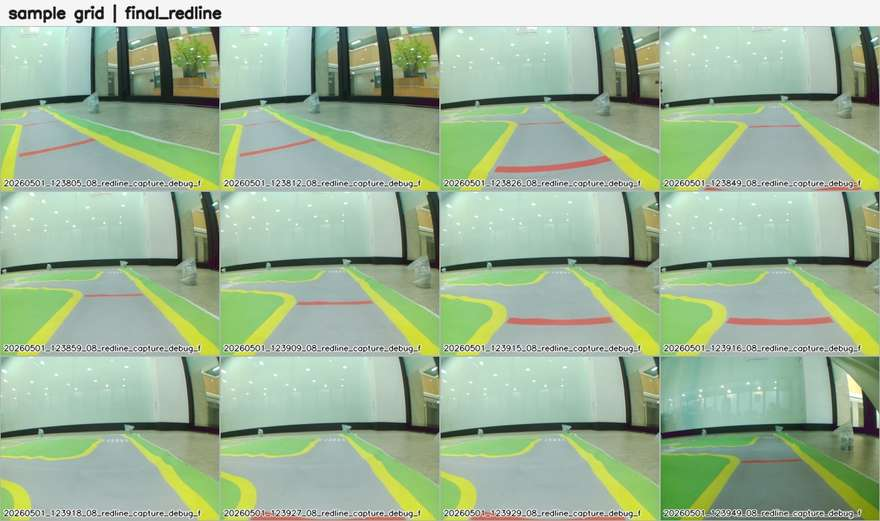

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\plots\sample_grid__stop_sign_negative.jpg


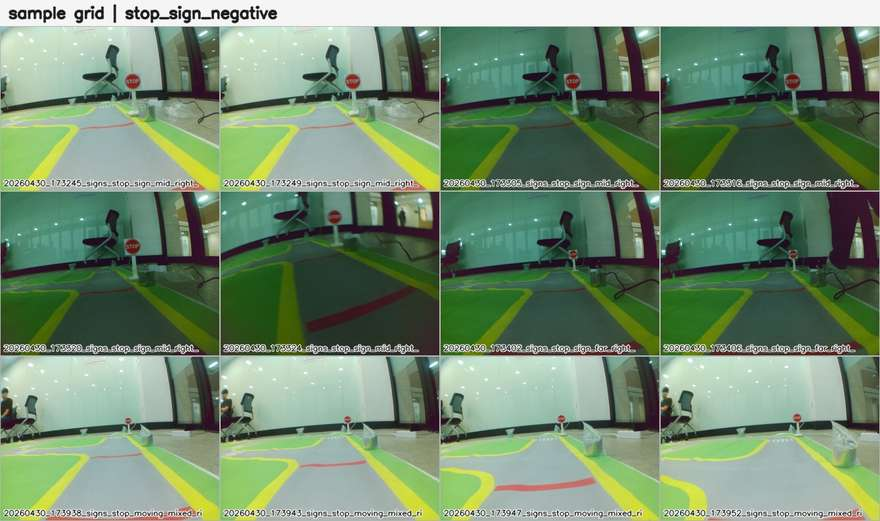

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\plots\sample_grid__traffic_red.jpg


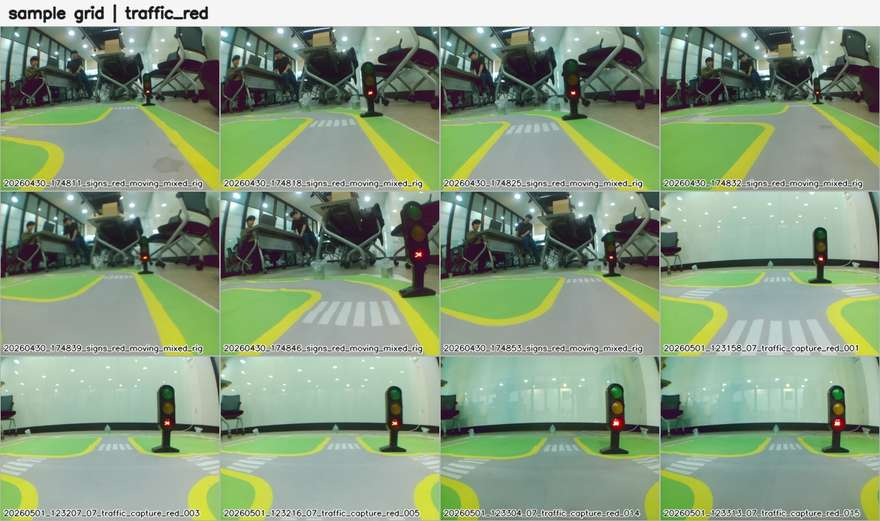

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\plots\sample_grid__traffic_green.jpg


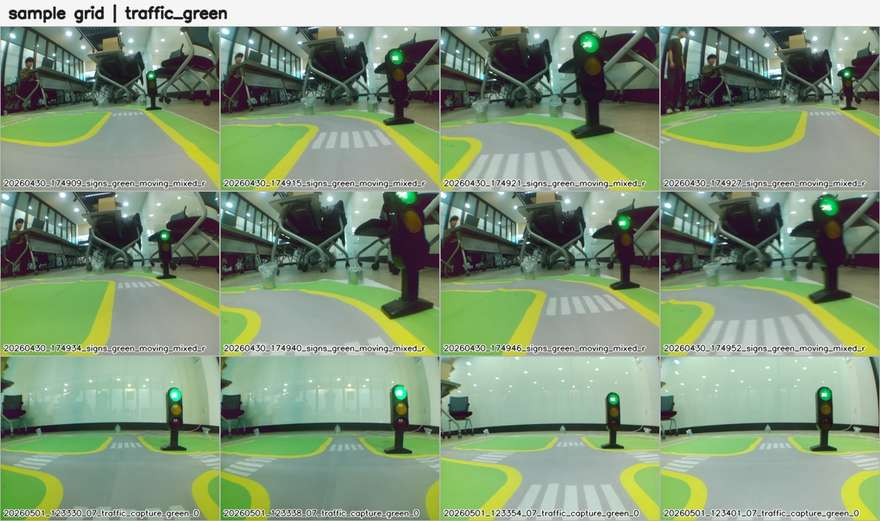

In [4]:
def sample_records(role, n=12):
    df = index_df[index_df['role'] == role].reset_index(drop=True)
    if len(df) <= n:
        return df
    idx = np.linspace(0, len(df) - 1, n, dtype=int)
    return df.iloc[idx].reset_index(drop=True)

def make_image_grid(records, out_path, title, cols=4, cell_w=320, cell_h=240):
    rows = int(math.ceil(len(records) / cols))
    canvas = np.full((rows * cell_h + 38, cols * cell_w, 3), 245, dtype=np.uint8)
    cv2.putText(canvas, title, (12, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (30, 30, 30), 2, cv2.LINE_AA)
    for i, rec in records.iterrows():
        bgr = imread_bgr(rec['path'])
        thumb = cv2.resize(bgr, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r = i // cols
        c = i % cols
        y0 = 38 + r * cell_h
        x0 = c * cell_w
        canvas[y0:y0+cell_h, x0:x0+cell_w] = thumb
        cv2.rectangle(canvas, (x0, y0), (x0+cell_w-1, y0+cell_h-1), (180, 180, 180), 1)
        text = rec['filename'][:42]
        cv2.putText(canvas, text, (x0 + 5, y0 + cell_h - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x0 + 5, y0 + cell_h - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (20, 20, 20), 1, cv2.LINE_AA)
    imwrite(out_path, canvas)
    return out_path

for role in ['final_redline', 'stop_sign_negative', 'traffic_red', 'traffic_green']:
    out = PLOT_DIR / f'sample_grid__{role}.jpg'
    make_image_grid(sample_records(role, 12), out, f'sample grid | {role}')
    print(out)
    show_saved_image(out, width=1000)


## HSV 후보 마스크

처음에는 traffic red에서 썼던 빨간색 후보를 redline 쪽에도 적용해 본다. 여기서 중요한 것은 final redline이 잘 잡히는지만이 아니다.

```text
좋은 후보:
  final redline에서 mask가 생긴다.
  stop sign에서도 mask는 생길 수 있지만, 형태가 compact라 contour에서 구분 가능해야 한다.
  traffic red/green에 대해서는 나중에 ROI로 대부분 제외될 수 있지만, 참고용으로 본다.
```

아직 ROI는 넣지 않는다. 색 자체의 분리력부터 본다.


In [5]:
HSV_CANDIDATES = [
    {
        'name': 'red_wide_s80_v70',
        'ranges': [((0, 80, 70), (14, 255, 255)), ((166, 80, 70), (179, 255, 255))],
        'note': '넓은 후보. 어두운 redline까지 잡는 대신 노이즈가 늘 수 있다.',
    },
    {
        'name': 'red_balanced_s100_v80',
        'ranges': [((0, 100, 80), (12, 255, 255)), ((168, 100, 80), (179, 255, 255))],
        'note': '기본 후보. 01d red_balanced와 비슷한 출발점.',
    },
    {
        'name': 'red_conservative_s130_v100',
        'ranges': [((0, 130, 100), (10, 255, 255)), ((170, 130, 100), (179, 255, 255))],
        'note': '보수 후보. stop sign/잡광은 줄지만 어두운 redline을 놓칠 수 있다.',
    },
    {
        'name': 'red_floor_dark_s70_v45',
        'ranges': [((0, 70, 45), (14, 255, 230)), ((166, 70, 45), (179, 255, 230))],
        'note': '바닥 반사와 저조도까지 보는 후보. 너무 넓을 가능성이 높다.',
    },
]

def hsv_mask_from_candidate(bgr, cand):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo, hi in cand['ranges']:
        part = cv2.inRange(hsv, np.array(lo, dtype=np.uint8), np.array(hi, dtype=np.uint8))
        mask = cv2.bitwise_or(mask, part)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask

def mask_ratio(mask):
    return float((mask > 0).mean())

def overlay_mask(bgr, mask, color_bgr=(0, 0, 255), alpha=0.55):
    out = bgr.copy()
    color = np.zeros_like(out)
    color[:, :] = color_bgr
    idx = mask > 0
    if np.any(idx):
        out[idx] = cv2.addWeighted(out[idx], 1.0 - alpha, color[idx], alpha, 0)
    return out


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_wide_s80_v70__final_redline.jpg


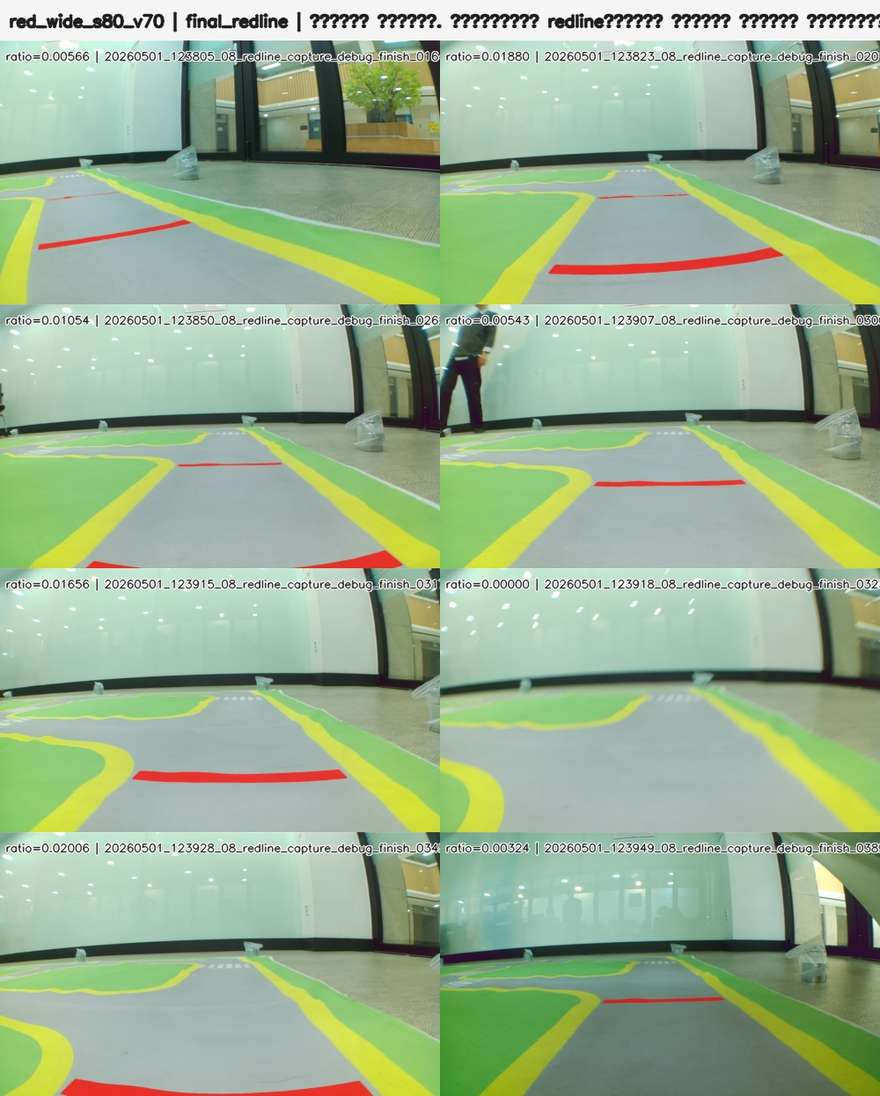

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_wide_s80_v70__stop_sign_negative.jpg


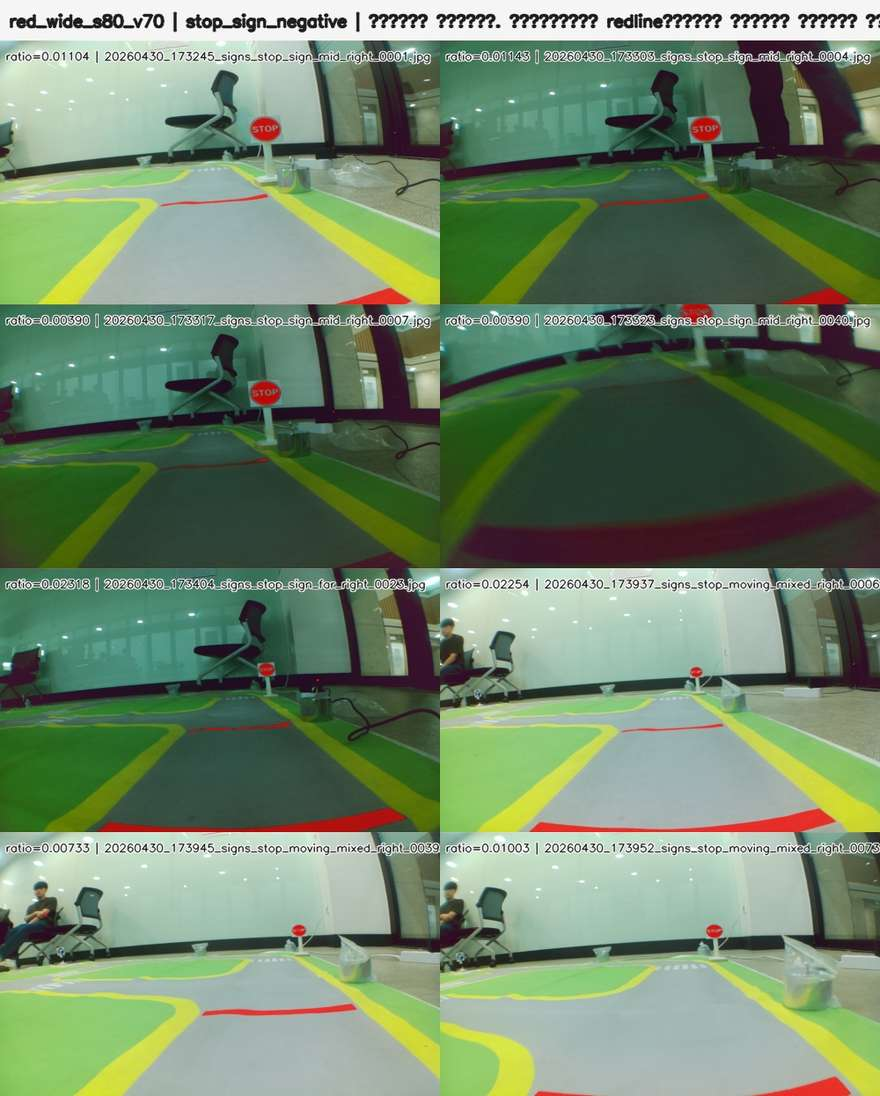

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_balanced_s100_v80__final_redline.jpg


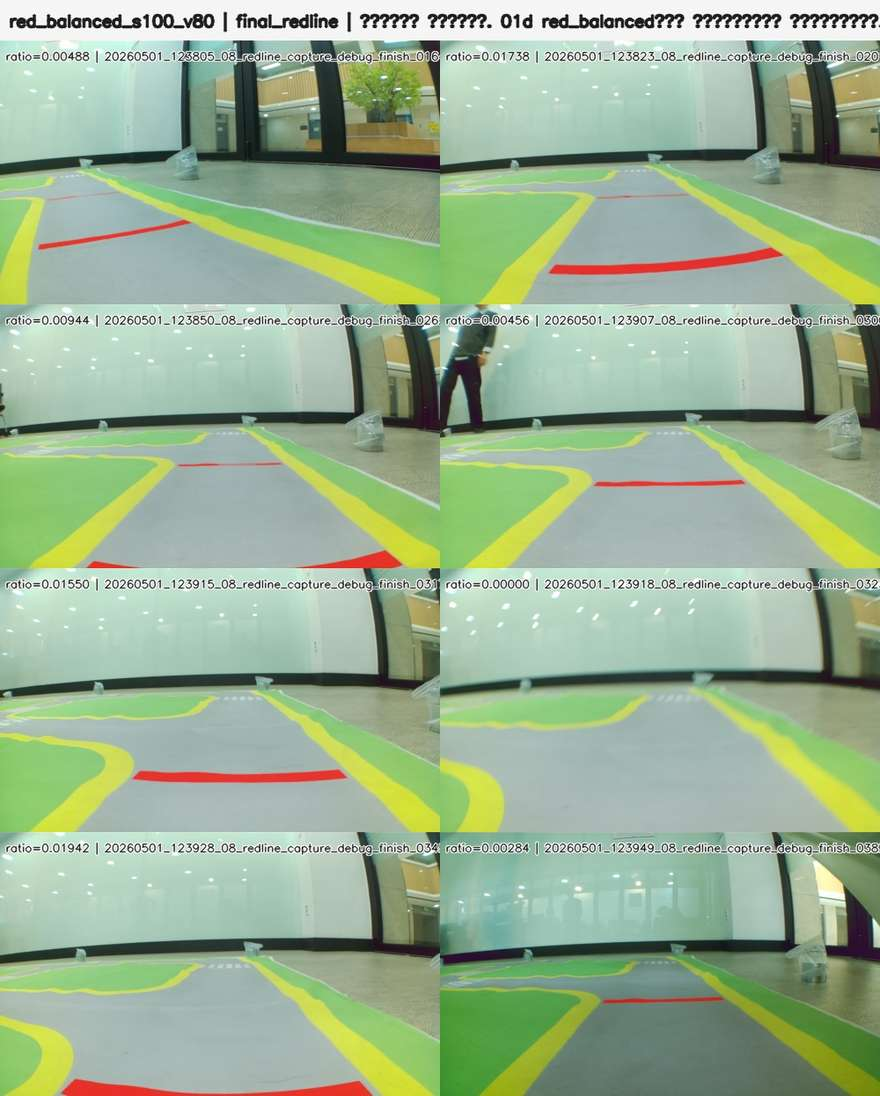

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_balanced_s100_v80__stop_sign_negative.jpg


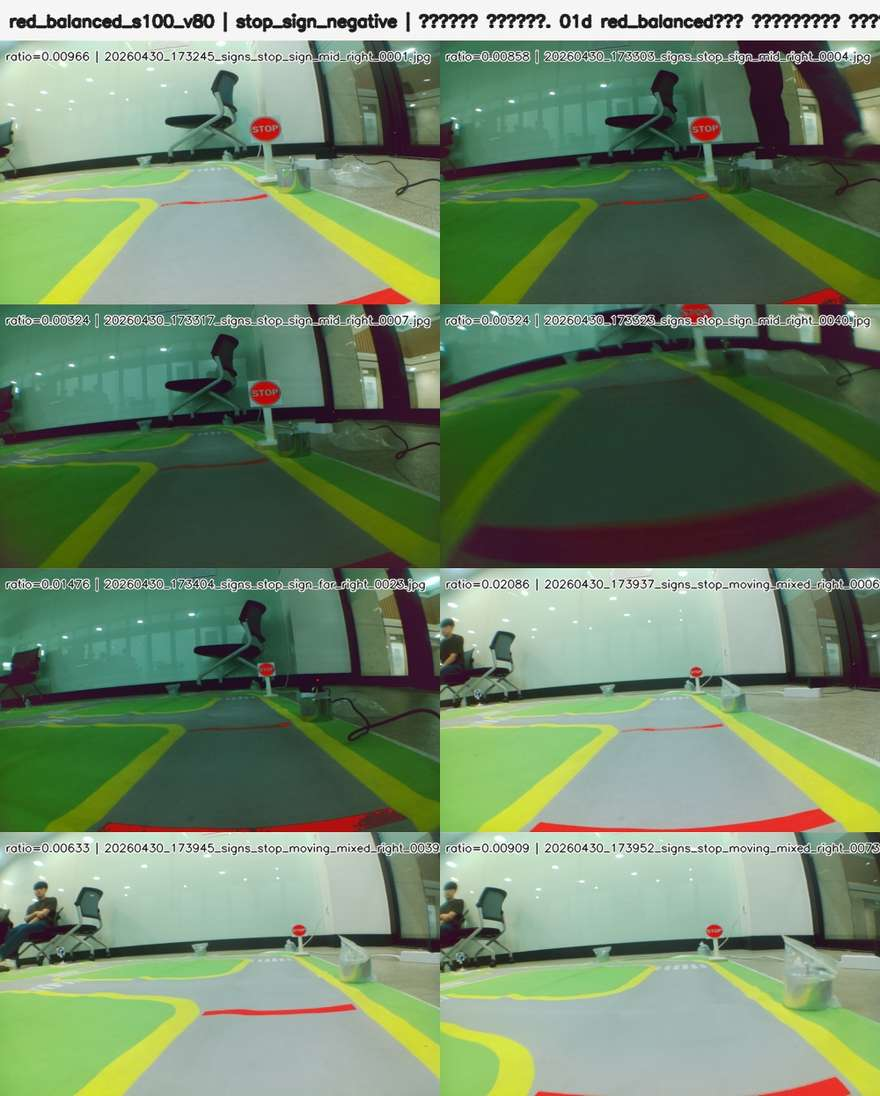

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_conservative_s130_v100__final_redline.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_conservative_s130_v100__stop_sign_negative.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_floor_dark_s70_v45__final_redline.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\mask__red_floor_dark_s70_v45__stop_sign_negative.jpg


In [6]:
def make_mask_sheet(cand, role, out_path, n=8, cols=2):
    records = sample_records(role, n)
    cell_w, cell_h = 500, 300
    rows = int(math.ceil(len(records) / cols))
    canvas = np.full((rows * cell_h + 46, cols * cell_w, 3), 245, dtype=np.uint8)
    title = f'{cand["name"]} | {role} | {cand.get("note", "")}'
    cv2.putText(canvas, title[:110], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (30, 30, 30), 2, cv2.LINE_AA)
    for i, rec in records.iterrows():
        bgr = imread_bgr(rec['path'])
        mask = hsv_mask_from_candidate(bgr, cand)
        over = overlay_mask(bgr, mask, color_bgr=(0, 0, 255), alpha=0.55)
        over = cv2.resize(over, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r, c = i // cols, i % cols
        y0, x0 = 46 + r * cell_h, c * cell_w
        canvas[y0:y0+cell_h, x0:x0+cell_w] = over
        text = f'ratio={mask_ratio(mask):.5f} | {rec["filename"][:54]}'
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (20, 20, 20), 1, cv2.LINE_AA)
    imwrite(out_path, canvas)
    return out_path

mask_sheet_paths = []
for cand in HSV_CANDIDATES:
    for role in ['final_redline', 'stop_sign_negative']:
        out = OVERLAY_DIR / f'mask__{cand["name"]}__{role}.jpg'
        make_mask_sheet(cand, role, out)
        mask_sheet_paths.append(out)
        print(out)
        show_saved_image(out, width=1000)


## HSV 후보별 mask 비율 요약

마스크 비율은 절대 성능 지표가 아니다. redline은 가까워질수록 커지고, 멀면 작다. 하지만 후보가 너무 넓어서 stop sign이나 배경 전체를 빨갛게 잡는지 확인하는 데에는 유용하다.


In [7]:
def summarize_masks(max_per_role=None):
    rows = []
    roles = ['final_redline', 'stop_sign_negative', 'traffic_red', 'traffic_green']
    for cand in HSV_CANDIDATES:
        for role in roles:
            df = index_df[index_df['role'] == role].reset_index(drop=True)
            if max_per_role is not None:
                df = df.head(max_per_role)
            ratios = []
            for _, rec in df.iterrows():
                bgr = imread_bgr(rec['path'])
                mask = hsv_mask_from_candidate(bgr, cand)
                ratios.append(mask_ratio(mask))
            ratios = np.array(ratios, dtype=np.float32)
            rows.append({
                'candidate': cand['name'],
                'role': role,
                'n': int(len(ratios)),
                'mask_ratio_mean': float(ratios.mean()) if len(ratios) else np.nan,
                'mask_ratio_median': float(np.median(ratios)) if len(ratios) else np.nan,
                'mask_ratio_p90': float(np.percentile(ratios, 90)) if len(ratios) else np.nan,
                'mask_ratio_max': float(ratios.max()) if len(ratios) else np.nan,
            })
    return pd.DataFrame(rows)

mask_summary = summarize_masks()
mask_summary.to_csv(TABLE_DIR / 'hsv_mask_ratio_summary.csv', index=False, encoding='utf-8-sig')
display(mask_summary.sort_values(['candidate', 'role']))


,candidate,role,n,mask_ratio_mean,mask_ratio_median,mask_ratio_p90,mask_ratio_max
4,red_balanced_s100_v80,final_redline,101,0.010993,0.009651,0.019293,0.026211
5,red_balanced_s100_v80,stop_sign_negative,233,0.010691,0.009717,0.020848,0.039607
7,red_balanced_s100_v80,traffic_green,313,0.000047,0.000029,0.000099,0.000480
6,red_balanced_s100_v80,traffic_red,343,0.001257,0.000848,0.002985,0.007071
8,red_conservative_s130_v100,final_redline,101,0.005363,0.000775,0.017164,0.019102
9,red_conservative_s130_v100,stop_sign_negative,233,0.003491,0.000499,0.008123,0.033666
11,red_conservative_s130_v100,traffic_green,313,0.000003,0.000000,0.000010,0.000045
10,red_conservative_s130_v100,traffic_red,343,0.000818,0.000521,0.002348,0.004564
12,red_floor_dark_s70_v45,final_redline,101,0.012338,0.011083,0.020348,0.040706
13,red_floor_dark_s70_v45,stop_sign_negative,233,0.022826,0.015654,0.028129,0.152983


## Contour feature 추출

여기서 contour는 mask에서 연결된 빨간 영역의 외곽선이다. 이후 판단은 bbox와 contour 면적을 같이 본다.

redline 후보가 가져야 할 직관은 아래와 같다.

```text
final redline:
  바닥 근처에 있고, 가로로 길다.
  bbox width가 크고, width / height가 크다.

stop sign:
  빨갛지만 compact object다.
  bbox가 정사각형에 가깝거나 세로형이고, 바닥의 긴 가로선이 아니다.
```

이 단계에서도 아직 최종 ROI를 확정하지 않는다. 다만 y 위치와 aspect ratio가 어느 정도 구분력을 갖는지 본다.


In [8]:
def find_red_contours(mask, min_area=20):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    feats = []
    H, W = mask.shape[:2]
    for cnt in contours:
        area = float(cv2.contourArea(cnt))
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        bbox_area = float(max(1, w * h))
        feats.append({
            'area': area,
            'x': int(x), 'y': int(y), 'w': int(w), 'h': int(h),
            'cx': float((x + w / 2) / W),
            'cy': float((y + h / 2) / H),
            'bottom_y': float((y + h) / H),
            'width_ratio': float(w / W),
            'height_ratio': float(h / H),
            'aspect_wh': float(w / max(1, h)),
            'fill': float(area / bbox_area),
        })
    feats.sort(key=lambda d: d['area'], reverse=True)
    return feats

def draw_contours(bgr, feats, color=(0, 0, 255), max_draw=8):
    out = bgr.copy()
    for i, f in enumerate(feats[:max_draw]):
        x, y, w, h = f['x'], f['y'], f['w'], f['h']
        cv2.rectangle(out, (x, y), (x+w, y+h), color, 2)
        txt = f"#{i+1} a={f['area']:.0f} ar={f['aspect_wh']:.1f} cy={f['cy']:.2f}"
        cv2.putText(out, txt, (x, max(18, y-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(out, txt, (x, max(18, y-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.48, color, 1, cv2.LINE_AA)
    return out


In [9]:
def contour_feature_table(cand):
    rows = []
    for _, rec in index_df.iterrows():
        role = rec['role']
        if role not in ['final_redline', 'stop_sign_negative', 'traffic_red', 'traffic_green']:
            continue
        bgr = imread_bgr(rec['path'])
        mask = hsv_mask_from_candidate(bgr, cand)
        feats = find_red_contours(mask, min_area=20)
        if feats:
            best = feats[0]
            row = {'candidate': cand['name'], 'role': role, 'filename': rec['filename'], 'path': rec['path'], 'num_contours': len(feats)}
            row.update({f'best_{k}': v for k, v in best.items()})
        else:
            row = {'candidate': cand['name'], 'role': role, 'filename': rec['filename'], 'path': rec['path'], 'num_contours': 0}
        rows.append(row)
    return pd.DataFrame(rows)

all_contour_tables = []
for cand in HSV_CANDIDATES:
    df = contour_feature_table(cand)
    all_contour_tables.append(df)
contour_df = pd.concat(all_contour_tables, ignore_index=True)
contour_df.to_csv(TABLE_DIR / 'contour_features_by_hsv_candidate.csv', index=False, encoding='utf-8-sig')

summary_cols = ['best_area', 'best_w', 'best_h', 'best_aspect_wh', 'best_cy', 'best_bottom_y', 'best_width_ratio']
contour_summary = (
    contour_df
    .groupby(['candidate', 'role'])
    .agg(
        n=('filename', 'count'),
        detect_pct=('num_contours', lambda s: float((s > 0).mean() * 100.0)),
        area_median=('best_area', 'median'),
        w_median=('best_w', 'median'),
        h_median=('best_h', 'median'),
        aspect_median=('best_aspect_wh', 'median'),
        cy_median=('best_cy', 'median'),
        bottom_y_median=('best_bottom_y', 'median'),
        width_ratio_median=('best_width_ratio', 'median'),
    )
    .reset_index()
)
contour_summary.to_csv(TABLE_DIR / 'contour_feature_summary.csv', index=False, encoding='utf-8-sig')
display(contour_summary)


,candidate,role,n,detect_pct,area_median,w_median,h_median,aspect_median,cy_median,bottom_y_median,width_ratio_median
0,red_balanced_s100_v80,final_redline,101,94.059406,18870.50,627.0,62.0,13.652174,0.788066,0.811728,0.483796
1,red_balanced_s100_v80,stop_sign_negative,233,99.141631,6507.00,289.0,81.0,4.823529,0.822531,0.870370,0.222994
2,red_balanced_s100_v80,traffic_green,313,50.798722,54.50,17.0,5.0,3.200000,0.148148,0.151235,0.013117
3,red_balanced_s100_v80,traffic_red,343,100.000000,1299.50,44.0,41.0,1.105263,0.404835,0.421811,0.033951
4,red_conservative_s130_v100,final_redline,101,63.366337,8100.75,295.0,46.5,7.875369,0.923611,0.955761,0.227623
5,red_conservative_s130_v100,stop_sign_negative,233,88.412017,358.25,35.0,20.0,1.896809,0.397634,0.403292,0.027006
6,red_conservative_s130_v100,traffic_green,313,3.833866,26.75,12.0,4.0,3.708333,0.130658,0.133230,0.009259
7,red_conservative_s130_v100,traffic_red,343,94.460641,623.75,38.0,35.0,1.073171,0.404835,0.420782,0.029321
8,red_floor_dark_s70_v45,final_redline,101,94.059406,20815.50,632.0,63.0,13.018868,0.787551,0.812757,0.487654
9,red_floor_dark_s70_v45,stop_sign_negative,233,100.000000,11924.50,486.0,78.0,7.134021,0.954733,1.000000,0.375000


## Contour 후보를 그려서 보기

아래 이미지는 각 HSV 후보에서 가장 큰 contour들을 bbox로 그린다. 여기서는 아직 pass/fail을 확정하지 않고, `final_redline`과 `stop_sign_negative`가 형태상 얼마나 분리되는지 눈으로 본다.


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_wide_s80_v70__final_redline.jpg


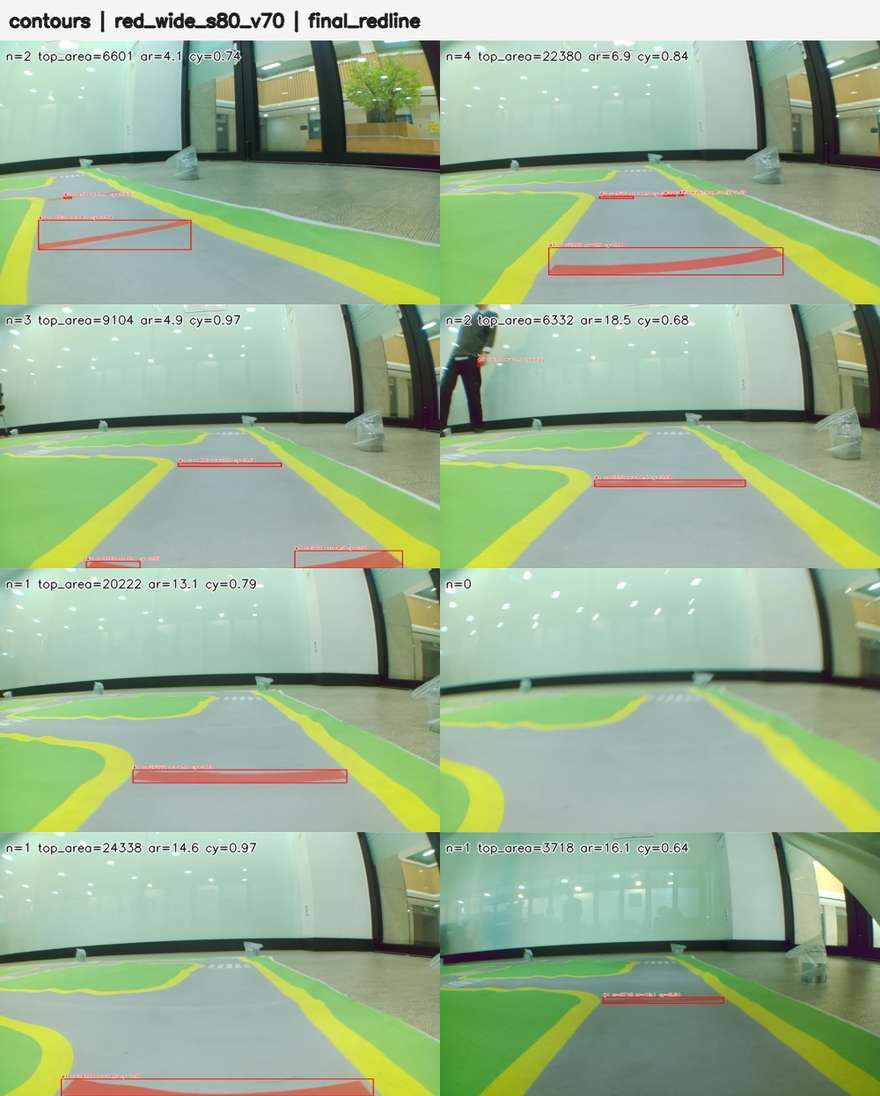

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_wide_s80_v70__stop_sign_negative.jpg


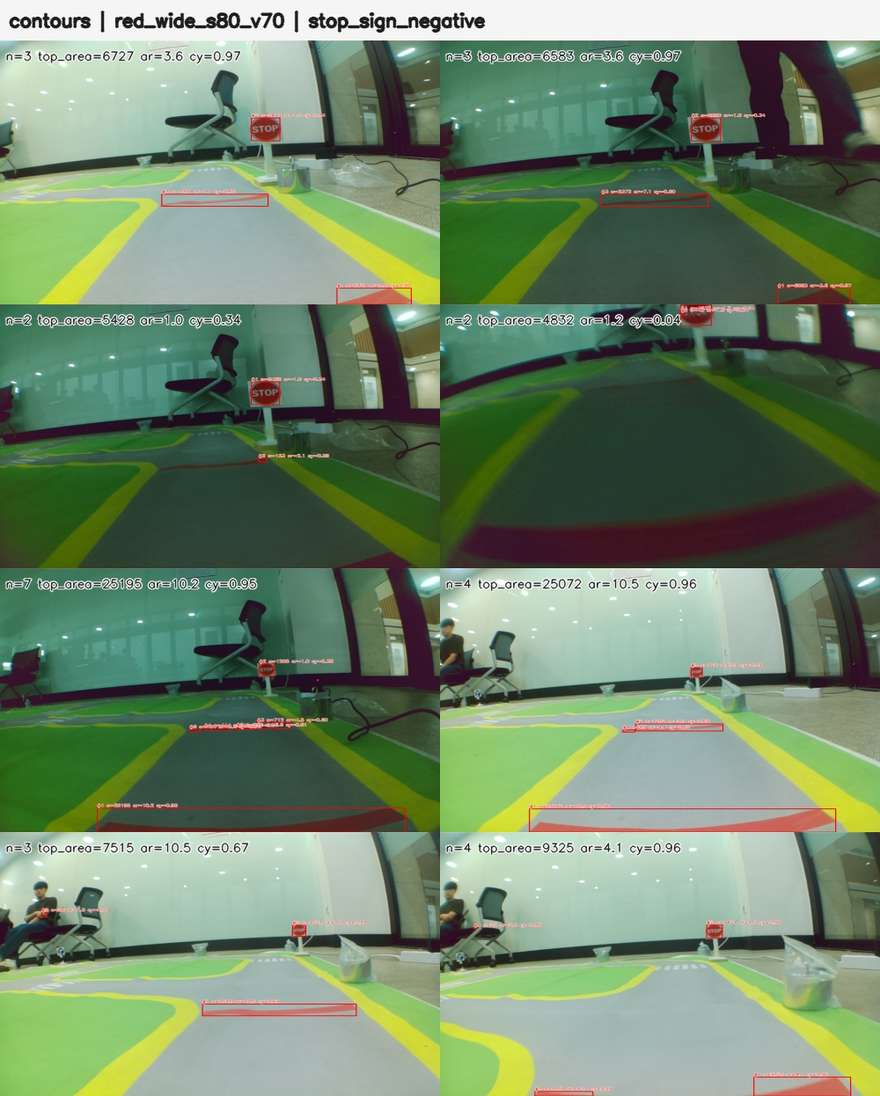

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_balanced_s100_v80__final_redline.jpg


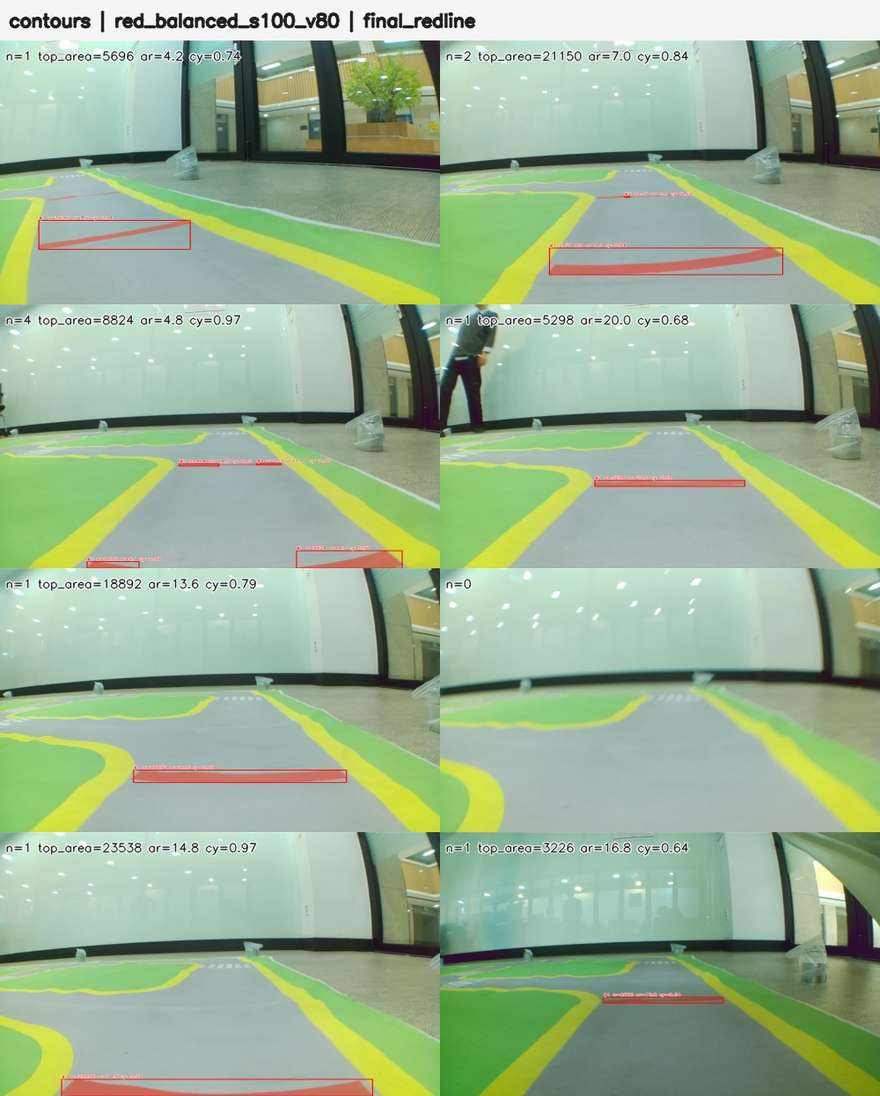

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_balanced_s100_v80__stop_sign_negative.jpg


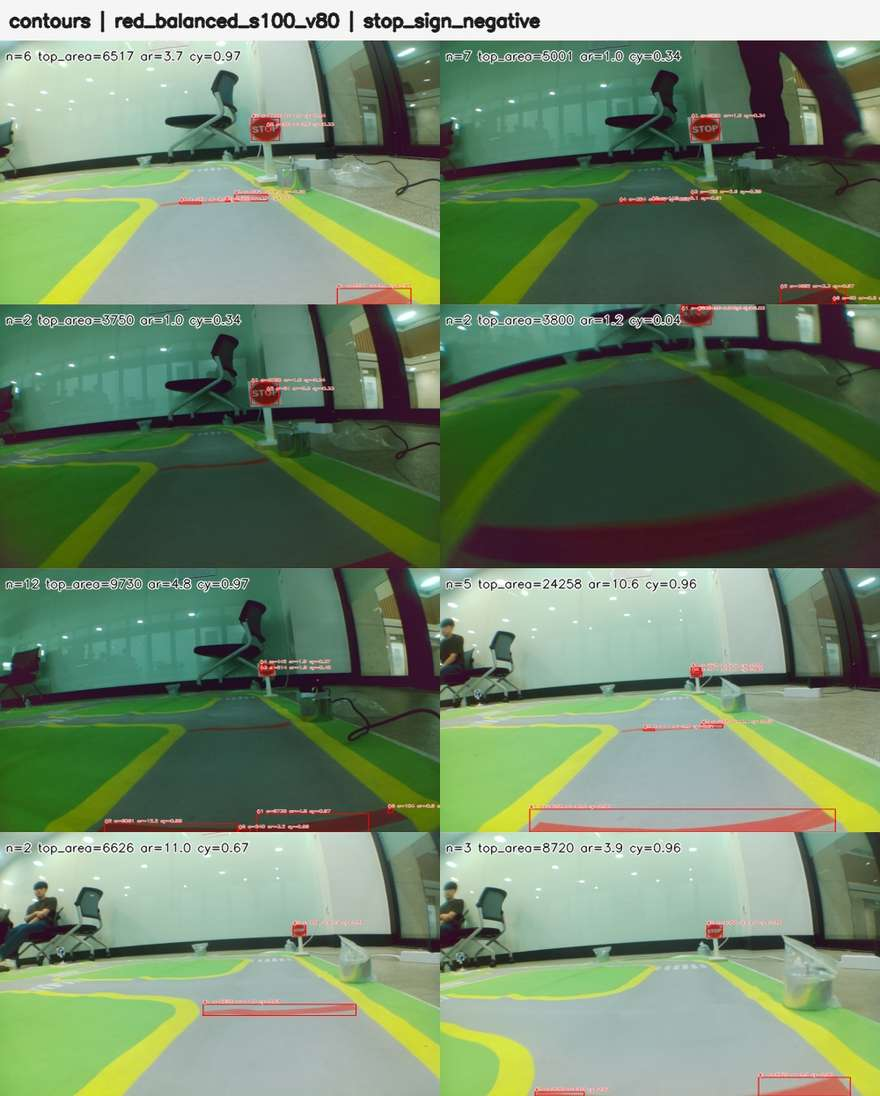

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_conservative_s130_v100__final_redline.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_conservative_s130_v100__stop_sign_negative.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_floor_dark_s70_v45__final_redline.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\contour__red_floor_dark_s70_v45__stop_sign_negative.jpg


In [10]:
def make_contour_sheet(cand, role, out_path, n=8, cols=2):
    records = sample_records(role, n)
    cell_w, cell_h = 500, 300
    rows = int(math.ceil(len(records) / cols))
    canvas = np.full((rows * cell_h + 46, cols * cell_w, 3), 245, dtype=np.uint8)
    title = f'contours | {cand["name"]} | {role}'
    cv2.putText(canvas, title[:110], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.68, (30, 30, 30), 2, cv2.LINE_AA)
    for i, rec in records.iterrows():
        bgr = imread_bgr(rec['path'])
        mask = hsv_mask_from_candidate(bgr, cand)
        feats = find_red_contours(mask, min_area=20)
        drawn = draw_contours(bgr, feats, color=(0, 0, 255), max_draw=6)
        drawn = cv2.resize(drawn, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r, c = i // cols, i % cols
        y0, x0 = 46 + r * cell_h, c * cell_w
        canvas[y0:y0+cell_h, x0:x0+cell_w] = drawn
        if feats:
            top = feats[0]
            text = f'n={len(feats)} top_area={top["area"]:.0f} ar={top["aspect_wh"]:.1f} cy={top["cy"]:.2f}'
        else:
            text = 'n=0'
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (20,20,20), 1, cv2.LINE_AA)
    imwrite(out_path, canvas)
    return out_path

for cand in HSV_CANDIDATES:
    for role in ['final_redline', 'stop_sign_negative']:
        out = OVERLAY_DIR / f'contour__{cand["name"]}__{role}.jpg'
        make_contour_sheet(cand, role, out)
        print(out)
        show_saved_image(out, width=1000)


## 임시 horizontal contour filter

아래 filter들은 contract가 아니다. `final_redline`과 `stop_sign_negative`를 분리할 수 있는 형태 조건이 있는지 보기 위한 실험값이다.

특히 `aspect_wh`와 `bottom_y`를 본다.

```text
aspect_wh가 크다  -> 가로로 길다.
bottom_y가 크다   -> 이미지 하단에 있다.
width_ratio가 크다 -> 화면에서 차지하는 가로 길이가 크다.
```

이 조건들이 먹히면 다음 노트북에서 ROI/event trigger 후보를 좁힐 수 있다.


In [11]:
HORIZONTAL_FILTERS = [
    {
        'name': 'horizontal_loose_no_y',
        'min_area': 180,
        'min_w': 35,
        'min_h': 3,
        'min_aspect_wh': 2.0,
        'min_width_ratio': 0.025,
        'min_bottom_y': 0.00,
        'min_fill': 0.03,
    },
    {
        'name': 'horizontal_floor_loose',
        'min_area': 250,
        'min_w': 45,
        'min_h': 3,
        'min_aspect_wh': 2.2,
        'min_width_ratio': 0.035,
        'min_bottom_y': 0.48,
        'min_fill': 0.04,
    },
    {
        'name': 'horizontal_floor_balanced',
        'min_area': 600,
        'min_w': 80,
        'min_h': 5,
        'min_aspect_wh': 3.0,
        'min_width_ratio': 0.060,
        'min_bottom_y': 0.55,
        'min_fill': 0.05,
    },
    {
        'name': 'horizontal_floor_near',
        'min_area': 1300,
        'min_w': 130,
        'min_h': 7,
        'min_aspect_wh': 3.5,
        'min_width_ratio': 0.100,
        'min_bottom_y': 0.60,
        'min_fill': 0.06,
    },
]

def passes_horizontal_filter(feat, filt):
    return (
        feat['area'] >= filt['min_area'] and
        feat['w'] >= filt['min_w'] and
        feat['h'] >= filt['min_h'] and
        feat['aspect_wh'] >= filt['min_aspect_wh'] and
        feat['width_ratio'] >= filt['min_width_ratio'] and
        feat['bottom_y'] >= filt['min_bottom_y'] and
        feat['fill'] >= filt['min_fill']
    )

def evaluate_horizontal_filters():
    rows = []
    detail_rows = []
    roles = ['final_redline', 'stop_sign_negative', 'traffic_red', 'traffic_green']
    for cand in HSV_CANDIDATES:
        for filt in HORIZONTAL_FILTERS:
            for role in roles:
                df = index_df[index_df['role'] == role].reset_index(drop=True)
                hits = 0
                for _, rec in df.iterrows():
                    bgr = imread_bgr(rec['path'])
                    mask = hsv_mask_from_candidate(bgr, cand)
                    feats = find_red_contours(mask, min_area=20)
                    passed = [f for f in feats if passes_horizontal_filter(f, filt)]
                    is_hit = len(passed) > 0
                    hits += int(is_hit)
                    if is_hit:
                        best = sorted(passed, key=lambda x: x['area'], reverse=True)[0]
                        d = {'candidate': cand['name'], 'filter': filt['name'], 'role': role, 'filename': rec['filename'], 'path': rec['path']}
                        d.update({f'best_{k}': v for k, v in best.items()})
                        detail_rows.append(d)
                rows.append({
                    'candidate': cand['name'],
                    'filter': filt['name'],
                    'role': role,
                    'n': int(len(df)),
                    'hit_count': int(hits),
                    'hit_pct': float(100.0 * hits / max(1, len(df))),
                })
    return pd.DataFrame(rows), pd.DataFrame(detail_rows)

horizontal_summary, horizontal_detail = evaluate_horizontal_filters()
horizontal_summary.to_csv(TABLE_DIR / 'horizontal_filter_summary.csv', index=False, encoding='utf-8-sig')
horizontal_detail.to_csv(TABLE_DIR / 'horizontal_filter_hit_details.csv', index=False, encoding='utf-8-sig')

pivot = horizontal_summary.pivot_table(index=['candidate', 'filter'], columns='role', values='hit_pct').reset_index()
# 탐색용 정렬: final_redline hit가 높고 stop/traffic false가 낮은 후보를 위로.
pivot['negative_max_hit_pct'] = pivot[['stop_sign_negative', 'traffic_red', 'traffic_green']].max(axis=1)
pivot['score_probe'] = pivot['final_redline'] - 1.5 * pivot['negative_max_hit_pct']
display(pivot.sort_values('score_probe', ascending=False))


role,candidate,filter,final_redline,stop_sign_negative,traffic_green,traffic_red,negative_max_hit_pct,score_probe
5,red_conservative_s130_v100,horizontal_floor_loose,52.475248,24.034335,0.000000,0.000000,24.034335,16.423745
6,red_conservative_s130_v100,horizontal_floor_near,44.554455,23.175966,0.000000,0.000000,23.175966,9.790507
4,red_conservative_s130_v100,horizontal_floor_balanced,44.554455,23.605150,0.000000,0.000000,23.605150,9.146730
7,red_conservative_s130_v100,horizontal_loose_no_y,53.465347,36.480687,0.000000,0.291545,36.480687,-1.255684
2,red_balanced_s100_v80,horizontal_floor_near,93.069307,64.806867,0.000000,0.874636,64.806867,-4.140993
0,red_balanced_s100_v80,horizontal_floor_balanced,93.069307,69.098712,0.000000,0.874636,69.098712,-10.578762
1,red_balanced_s100_v80,horizontal_floor_loose,94.059406,70.386266,0.000000,0.874636,70.386266,-11.519993
13,red_wide_s80_v70,horizontal_floor_loose,94.059406,73.819742,0.000000,0.874636,73.819742,-16.670208
14,red_wide_s80_v70,horizontal_floor_near,93.069307,73.390558,0.000000,0.874636,73.390558,-17.016530
12,red_wide_s80_v70,horizontal_floor_balanced,93.069307,73.819742,0.000000,0.874636,73.819742,-17.660307


## 임시 filter overlay

가장 좋아 보이는 후보 몇 개를 눈으로 확인한다. 여기서 중요한 질문은 하나다.

```text
이 bbox가 정말 final redline을 잡고 있는가?
stop sign이나 traffic red에서 같은 filter가 잘못 pass하지 않는가?
```


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_balanced__final_redline__hit.jpg


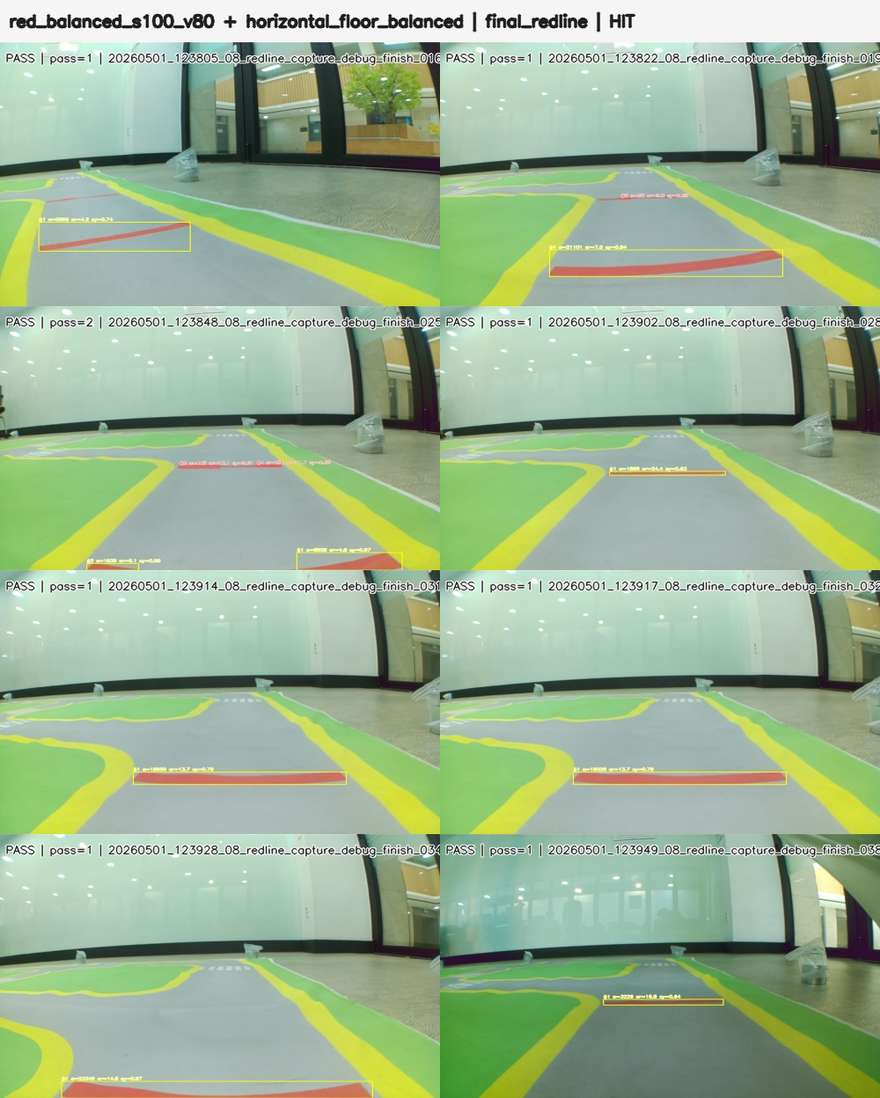

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_balanced__final_redline__miss.jpg


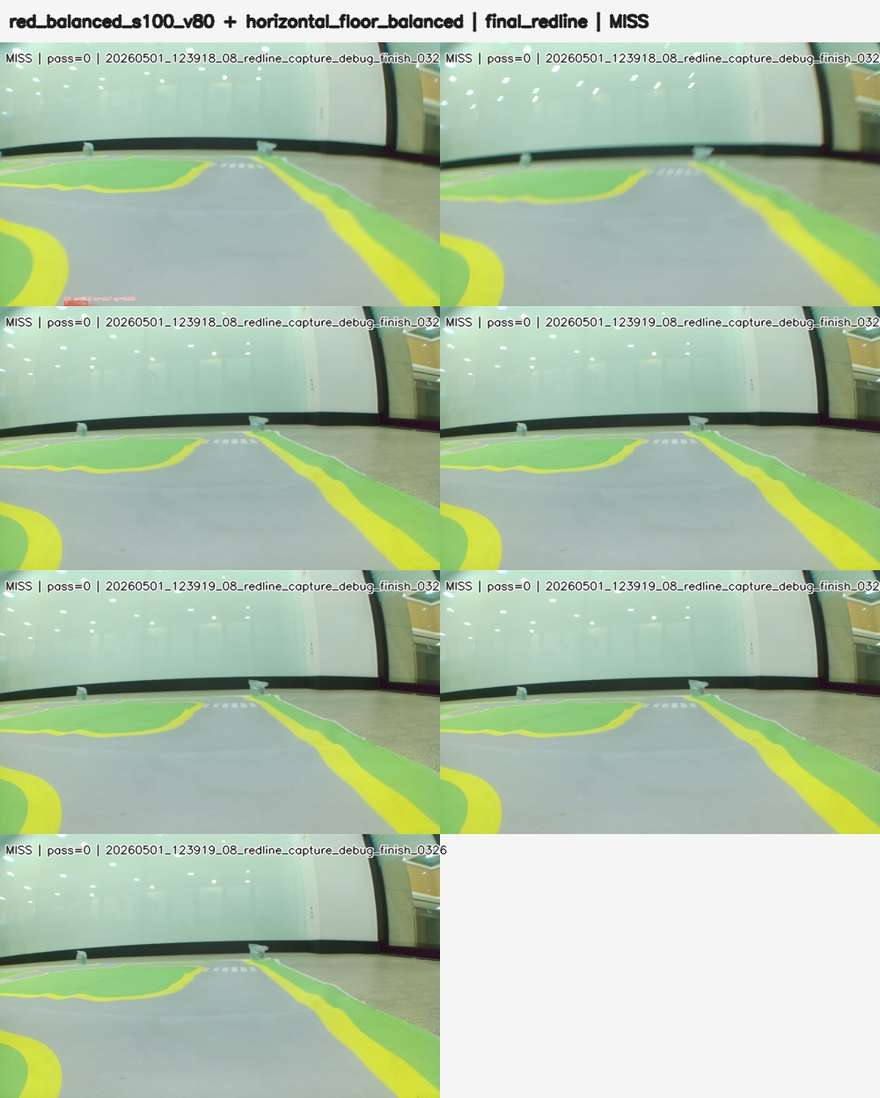

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_balanced__stop_sign_negative__hit.jpg


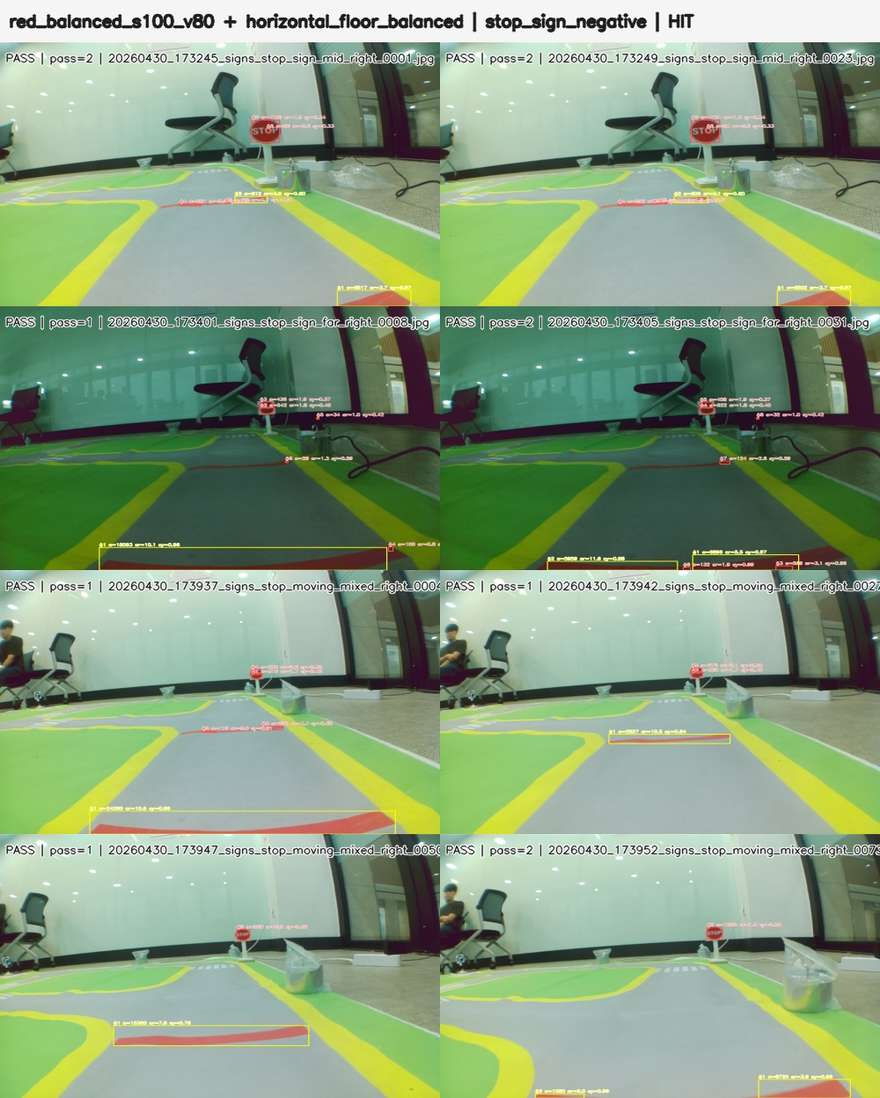

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_balanced__traffic_red__hit.jpg


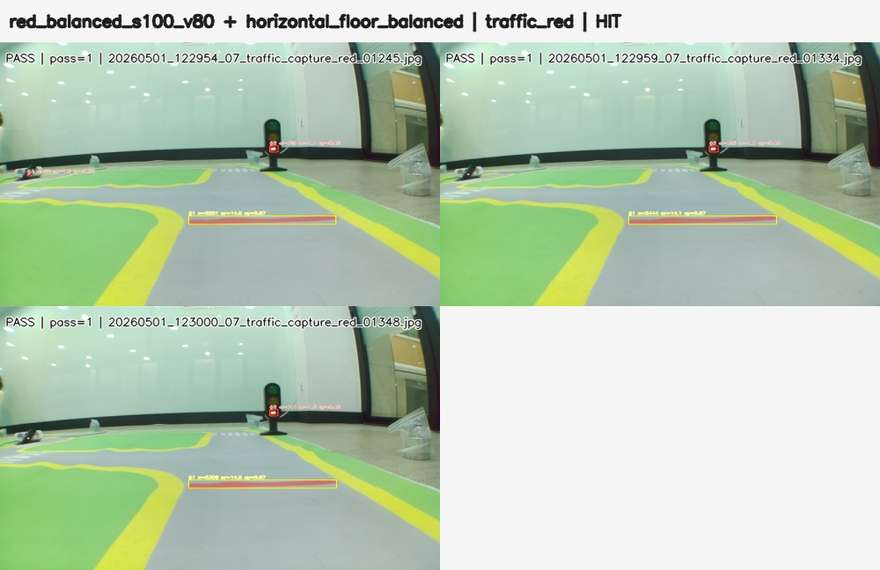

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_near__final_redline__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_near__final_redline__miss.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_near__stop_sign_negative__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_balanced_s100_v80__horizontal_floor_near__traffic_red__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_conservative_s130_v100__horizontal_floor_balanced__final_redline__hit.jpg


...

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_conservative_s130_v100__horizontal_floor_balanced__stop_sign_negative__hit.jpg


no rows: red_conservative_s130_v100 horizontal_floor_balanced traffic_red want_hit= True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_wide_s80_v70__horizontal_floor_near__final_redline__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_wide_s80_v70__horizontal_floor_near__final_redline__miss.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_wide_s80_v70__horizontal_floor_near__stop_sign_negative__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02_redline_color_contour_probe_v1\overlays\passfail__red_wide_s80_v70__horizontal_floor_near__traffic_red__hit.jpg


In [12]:
def make_pass_fail_sheet(cand_name, filt_name, role, out_path, want_hit=True, n=8, cols=2):
    cand = next(c for c in HSV_CANDIDATES if c['name'] == cand_name)
    filt = next(f for f in HORIZONTAL_FILTERS if f['name'] == filt_name)
    df = index_df[index_df['role'] == role].reset_index(drop=True)
    selected = []
    for _, rec in df.iterrows():
        bgr = imread_bgr(rec['path'])
        mask = hsv_mask_from_candidate(bgr, cand)
        feats = find_red_contours(mask, min_area=20)
        passed = [f for f in feats if passes_horizontal_filter(f, filt)]
        is_hit = len(passed) > 0
        if is_hit == want_hit:
            selected.append((rec, passed if is_hit else feats))
    if not selected:
        print('no rows:', cand_name, filt_name, role, 'want_hit=', want_hit)
        return None
    # evenly sample selected rows
    idx = np.linspace(0, len(selected) - 1, min(n, len(selected)), dtype=int)
    selected = [selected[i] for i in idx]
    cell_w, cell_h = 500, 300
    rows = int(math.ceil(len(selected) / cols))
    canvas = np.full((rows * cell_h + 48, cols * cell_w, 3), 245, dtype=np.uint8)
    title = f'{cand_name} + {filt_name} | {role} | {"HIT" if want_hit else "MISS"}'
    cv2.putText(canvas, title[:110], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (30,30,30), 2, cv2.LINE_AA)
    for i, (rec, feats) in enumerate(selected):
        bgr = imread_bgr(rec['path'])
        mask = hsv_mask_from_candidate(bgr, cand)
        feats_all = find_red_contours(mask, min_area=20)
        passed = [f for f in feats_all if passes_horizontal_filter(f, filt)]
        drawn = bgr.copy()
        # draw all red contours lightly, passed contours strongly
        drawn = draw_contours(drawn, feats_all, color=(80, 80, 255), max_draw=10)
        drawn = draw_contours(drawn, passed, color=(0, 255, 255), max_draw=10)
        drawn = cv2.resize(drawn, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r, c = i // cols, i % cols
        y0, x0 = 48 + r * cell_h, c * cell_w
        canvas[y0:y0+cell_h, x0:x0+cell_w] = drawn
        label = 'PASS' if passed else 'MISS'
        text = f'{label} | pass={len(passed)} | {rec["filename"][:52]}'
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x0 + 6, y0 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (20,20,20), 1, cv2.LINE_AA)
    imwrite(out_path, canvas)
    return out_path

# 숫자 결과를 보고 바꿔보기 쉬운 후보 목록이다. 처음엔 넓은 후보와 balanced 후보를 비교한다.
SHORTLIST_TO_VIEW = [
    ('red_balanced_s100_v80', 'horizontal_floor_balanced'),
    ('red_balanced_s100_v80', 'horizontal_floor_near'),
    ('red_conservative_s130_v100', 'horizontal_floor_balanced'),
    ('red_wide_s80_v70', 'horizontal_floor_near'),
]

for cand_name, filt_name in SHORTLIST_TO_VIEW:
    for role, want_hit in [('final_redline', True), ('final_redline', False), ('stop_sign_negative', True), ('traffic_red', True)]:
        out = OVERLAY_DIR / f'passfail__{cand_name}__{filt_name}__{role}__{"hit" if want_hit else "miss"}.jpg'
        p = make_pass_fail_sheet(cand_name, filt_name, role, out, want_hit=want_hit, n=8)
        if p is not None:
            print(p)
            show_saved_image(p, width=1000)


## 읽는 법과 다음 단계

이 노트북을 다 실행한 뒤에는 아래 순서로 본다.

```text
1. hsv_mask_ratio_summary.csv
   - 어떤 HSV 후보가 너무 넓은지 확인한다.

2. contour_feature_summary.csv
   - final_redline과 stop_sign_negative의 bbox 형태가 얼마나 다른지 확인한다.

3. horizontal_filter_summary.csv
   - final_redline hit가 높고 stop/traffic false가 낮은 후보를 찾는다.

4. passfail overlay
   - 숫자상 좋아 보여도 실제 bbox가 redline이 아닌 바닥 반사나 다른 빨간 물체를 잡는지 확인한다.
```

다음 노트북에서는 이 결과를 바탕으로 `02a redline event trigger candidate`를 만든다. 그때는 ROI를 점진적으로 넣는다.

중요한 점: redline event는 멀리서 감지할 필요가 없다. 실제 이벤트는 차량이 final redline에 가까워졌을 때 발생해야 한다. 따라서 전체 hit rate보다, 가까운 redline에서 정확히 잡히고 stop sign false가 낮은 후보가 더 중요하다.
